# Model B + sharpness: main figures notebook

This notebook produces the main sharpness-based figures for the paper.

It uses two representative Model B cases:
- d=2 regular 3x3 GMM (hero visual case),
- d=8 hypercube-random 9-mode case (to show target dependence / non-universality).

Workflow in each case:
1. constant-beta scan,
2. choose best constant beta as warm start,
3. hierarchical optimization 1 -> 2 -> 4 -> 8,
4. compare best constant vs best PWC-8.

Objectives:
  $$\hat S(\beta) = \int_0^1 (1-\|2\hat{A}-1) dt$$
  $$ \hat S^{(reg)}(\beta) =\hat S + \lambda^{(trans)}  \|t^{(star)} - t^{(trans)}\|^2$$

where $t^{(star)}$ is the first crossing time of $\hat A(t)$ at level 1/2.

## Imports and repository bootstrap

In [9]:
import json
import itertools
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "lqgm_pid_ada").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "lqgm_pid_ada").exists():
            ROOT = parent
            break

if not (ROOT / "lqgm_pid_ada").exists():
    raise RuntimeError("Could not locate `lqgm_pid_ada`.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

from lqgm_pid_ada import (
    GaussianMixture,
    LQGMPID,
    auto_correlation,
    make_pwc_beta_spec,
)

## Global settings

In [10]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)
DEVICE = "cpu"

# Model B settings
A_GRID = 1.5
SIGMA = 0.3
K = 9

# Two main cases
D2_CASE = "regular_3x3_d2"
D8_CASE = "hypercube_random9_d8"

# d=8 random-seed choice for this notebook
D8_RANDOM_SEED = 303

# Hierarchy
LEVELS = [1, 2, 4, 8]
BETA_INIT = 1.0
BETA_MIN = 1e-3
BETA_MAX = 20.0

# Constant scans extended to 20
BETA_SWEEP_D2 = [0.05, 0.1, 0.18, 0.25, 0.35, 0.5, 0.7, 1.0, 1.4, 2.0, 2.8, 4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 18.0, 20.0]
BETA_SWEEP_D8 = [0.05, 0.1, 0.18, 0.25, 0.35, 0.5, 0.7, 1.0, 1.4, 2.0, 2.8, 4.0, 6.0, 8.0, 10.0, 12.0, 15.0, 18.0, 20.0]
BETA_SWEEP_BY_CASE = {D2_CASE: BETA_SWEEP_D2, D8_CASE: BETA_SWEEP_D8}

# Simulation
M_EVAL = 2000
T_EVAL = 500
SEED_SIM = 20241012

# Regularized sharpness
LAM_TRANS = 10.0
T_TRANS = 0.50

# Coordinate descent
STEP0 = 0.5
STEP_MIN = 1e-4
IMPROVE_TOL = 5e-4
MAX_SWEEPS = 20

# Output
FIG_DIR = ROOT / "figs" / "modelB_sharpness_main"
TABLE_DIR = ROOT / "tables" / "modelB_sharpness_main"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["savefig.dpi"] = 220

## Helpers

In [11]:
def savefig_all(fig, stem: str, folder=FIG_DIR, close=False):
    pdf_path = folder / f"{stem}.pdf"
    png_path = folder / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"saved: {pdf_path}")
    print(f"saved: {png_path}")
    if close:
        plt.close(fig)

def save_table(df: pd.DataFrame, stem: str, folder=TABLE_DIR):
    csv_path = folder / f"{stem}.csv"
    tex_path = folder / f"{stem}.tex"
    df.to_csv(csv_path, index=False)
    try:
        df.to_latex(tex_path, index=False, float_format=lambda x: f"{x:.6g}")
    except Exception:
        pass
    print(f"saved: {csv_path}")

def save_json(obj, stem: str, folder=TABLE_DIR):
    path = folder / f"{stem}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)
    print(f"saved: {path}")

def build_gaussian_mixture(weights, means, covs):
    tries = [
        lambda: GaussianMixture(weights=weights, means=means, covs=covs),
        lambda: GaussianMixture(means=means, covs=covs, weights=weights),
        lambda: GaussianMixture(weights, means, covs),
        lambda: GaussianMixture(means, covs, weights),
    ]
    last_err = None
    for ctor in tries:
        try:
            gmm = ctor()
            _ = gmm.weights
            _ = gmm.means
            _ = gmm.covs
            return gmm
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Could not construct GaussianMixture. Last error: {last_err}")

## Build Model B targets

In [12]:
def make_regular_3x3_gmm(a=A_GRID, sigma=SIGMA, device=DEVICE, dtype=torch.float64):
    xs = np.array([-a, 0.0, a], dtype=float)
    means_np = np.array([[xi, yj] for yj in xs for xi in xs], dtype=float)
    M = means_np.shape[0]
    covs_np = np.stack([sigma**2 * np.eye(2) for _ in range(M)], axis=0)
    weights_np = np.ones(M, dtype=float) / M

    means = torch.tensor(means_np, device=device, dtype=dtype)
    covs = torch.tensor(covs_np, device=device, dtype=dtype)
    weights = torch.tensor(weights_np, device=device, dtype=dtype)
    return build_gaussian_mixture(weights, means, covs), means_np, np.full(M, sigma)

def make_random_hypercube_gmm(d=8, K=9, a=A_GRID, sigma=SIGMA, seed=303, device=DEVICE, dtype=torch.float64):
    vals = np.array([-a, 0.0, a], dtype=float)
    all_centers = np.array(list(itertools.product(vals, repeat=d)), dtype=float)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(all_centers), size=K, replace=False)
    means_np = all_centers[idx]
    covs_np = np.stack([sigma**2 * np.eye(d) for _ in range(K)], axis=0)
    weights_np = np.ones(K, dtype=float) / K

    means = torch.tensor(means_np, device=device, dtype=dtype)
    covs = torch.tensor(covs_np, device=device, dtype=dtype)
    weights = torch.tensor(weights_np, device=device, dtype=dtype)
    return build_gaussian_mixture(weights, means, covs), means_np, np.full(K, sigma)

TARGETS = {}
TARGET_META = {}

gmm2, centers2, sigmas2 = make_regular_3x3_gmm()
TARGETS[D2_CASE] = gmm2
TARGET_META[D2_CASE] = {"d": 2, "centers": centers2, "sigmas": sigmas2, "seed": None}

gmm8, centers8, sigmas8 = make_random_hypercube_gmm(d=8, K=9, seed=D8_RANDOM_SEED)
TARGETS[D8_CASE] = gmm8
TARGET_META[D8_CASE] = {"d": 8, "centers": centers8, "sigmas": sigmas8, "seed": D8_RANDOM_SEED}

## PID builders and objective helpers

In [13]:
def build_pid(case_name, beta_values):
    d = TARGET_META[case_name]["d"]
    pspec = make_pwc_beta_spec(
        d=d,
        breaks=np.linspace(0.0, 1.0, len(beta_values) + 1).tolist(),
        beta_values=list(np.asarray(beta_values, dtype=float)),
        family="optimized_pwc",
        device=DEVICE,
        dtype=torch.float64,
    )
    proto = pspec.build()
    x0 = torch.zeros(d, device=DEVICE, dtype=torch.float64)
    pid = LQGMPID(proto, TARGETS[case_name], x0)
    pid.precompute()
    return pid

def interpolated_crossing_time(times, values, threshold=0.5, append_terminal_one=True):
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)

    if append_terminal_one and times[-1] < 1.0:
        times = np.concatenate([times, [1.0]])
        values = np.concatenate([values, [1.0]])

    idx = np.where(values >= threshold)[0]
    if len(idx) == 0:
        return 1.0

    i = idx[0]
    if i == 0:
        return float(times[0])

    t0, t1 = times[i - 1], times[i]
    y0, y1 = values[i - 1], values[i]
    if abs(y1 - y0) < 1e-14:
        return float(t1)

    frac = (threshold - y0) / (y1 - y0)
    frac = np.clip(frac, 0.0, 1.0)
    return float(t0 + frac * (t1 - t0))

def sharpness_integrand(Ahat):
    return 1.0 - np.abs(2.0 * Ahat - 1.0)

def summarize_auto_corr_result(ac):
    t = ac.times.detach().cpu().numpy()
    A = ac.A.detach().cpu().numpy()
    Ahat = ac.Ahat.detach().cpu().numpy()
    Shat = float(np.trapz(sharpness_integrand(Ahat), t))
    t_star = interpolated_crossing_time(t, Ahat, threshold=0.5, append_terminal_one=True)
    return {"times": t, "A": A, "Ahat": Ahat, "Shat": Shat, "t_star": t_star}

def evaluate_sharpness(case_name, beta_values, B=M_EVAL, n_steps=T_EVAL, seed=SEED_SIM):
    pid = build_pid(case_name, beta_values)
    sim = pid.simulate(B=B, n_steps=n_steps, seed=int(seed), dtype=torch.float64, device=DEVICE)
    ac = auto_correlation(pid, sim=sim, threshold=0.8)
    return summarize_auto_corr_result(ac)

def regularized_sharpness(info, lam_trans=LAM_TRANS, t_trans=T_TRANS):
    penalty = lam_trans * abs(float(info["t_star"]) - float(t_trans)) ** 2
    return float(info["Shat"] + penalty)

def regularization_penalty(info, lam_trans=LAM_TRANS, t_trans=T_TRANS):
    return float(lam_trans * abs(float(info["t_star"]) - float(t_trans)) ** 2)

def summarize_row(case_name, beta_values, info, kind, extra=None):
    row = {
        "case_name": case_name,
        "d": TARGET_META[case_name]["d"],
        "kind": kind,
        "betas": np.array2string(np.asarray(beta_values, dtype=float), precision=6, separator=", "),
        "Shat": float(info["Shat"]),
        "t_star": float(info["t_star"]),
        "penalty": regularization_penalty(info),
        "Sreg": float(regularized_sharpness(info)),
    }
    if extra is not None:
        row.update(extra)
    return row

## Coordinate descent and helpers

In [14]:
def objective_sharpness_reg(case_name, beta_values):
    info = evaluate_sharpness(case_name, beta_values)
    return regularized_sharpness(info)

def coord_descent_sharpness_reg(
    case_name,
    betas0,
    step0=STEP0,
    step_min=STEP_MIN,
    improve_tol=IMPROVE_TOL,
    max_sweeps=MAX_SWEEPS,
    beta_min=BETA_MIN,
    beta_max=BETA_MAX,
    record=None,
):
    b = np.asarray(betas0, dtype=float).copy()
    fbest = objective_sharpness_reg(case_name, b)
    if record is not None:
        record.append(float(fbest))

    step = float(step0)
    for _ in range(max_sweeps):
        improved = False
        for k in range(len(b)):
            for sgn in (+1, -1):
                cand = b.copy()
                cand[k] = np.clip(cand[k] + sgn * step, beta_min, beta_max)
                f = objective_sharpness_reg(case_name, cand)
                if f + improve_tol < fbest:
                    b, fbest = cand, f
                    improved = True
                    if record is not None:
                        record.append(float(fbest))
        if not improved:
            step *= 0.5
            if step < step_min:
                break
    return b, float(fbest)

def prolongate_parent_to_children(parent_betas, L):
    parent_betas = np.asarray(parent_betas, dtype=float)
    if len(parent_betas) == L:
        return parent_betas.copy()

    splitsL = np.linspace(0.0, 1.0, L + 1)
    parent_edges = np.linspace(0.0, 1.0, len(parent_betas) + 1)
    child = np.empty(L, dtype=float)
    for i in range(L):
        t_mid = 0.5 * (splitsL[i] + splitsL[i + 1])
        j = np.searchsorted(parent_edges, t_mid, side="right") - 1
        j = max(0, min(len(parent_betas) - 1, j))
        child[i] = parent_betas[j]
    return child

def step_plot_from_betas(betas):
    betas = np.asarray(betas, dtype=float)
    L = len(betas)
    edges = np.linspace(0.0, 1.0, L + 1)
    x = np.repeat(edges, 2)[1:-1]
    y = np.repeat(betas, 2)
    return x, y

## Visuals for d=2 regular 3x3 case

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_target_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_target_d2.png


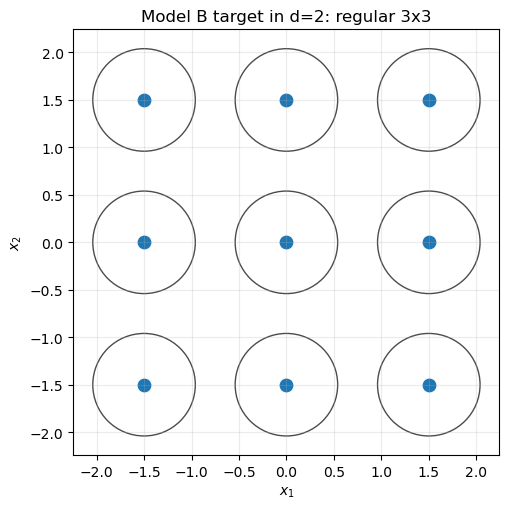

In [15]:
def plot_target_visual_d2():
    centers = TARGET_META[D2_CASE]["centers"]
    sigmas = TARGET_META[D2_CASE]["sigmas"]

    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.scatter(centers[:, 0], centers[:, 1], s=80)

    from matplotlib.patches import Circle
    for c, s in zip(centers, sigmas):
        ax.add_patch(Circle((c[0], c[1]), 1.8 * s, fill=False, alpha=0.7))

    ax.set_title("Model B target in d=2: regular 3x3")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    savefig_all(fig, "fig_modelB_target_d2")

plot_target_visual_d2()

## Constant-beta scans

In [16]:
const_rows = []
const_infos = {}

for case_name in [D2_CASE, D8_CASE]:
    print("=" * 80)
    print(f"Constant-beta scan for {case_name}")

    for beta in BETA_SWEEP_BY_CASE[case_name]:
        beta_values = [beta]
        info = evaluate_sharpness(case_name, beta_values)
        row = summarize_row(case_name, beta_values, info, "constant_scan", extra={"beta_const": beta})
        const_rows.append(row)
        const_infos[(case_name, beta)] = info

        print(
            f"case={case_name} | beta={beta:>5g} | "
            f"Shat={row['Shat']:.6f} | t_star={row['t_star']:.6f} | "
            f"penalty={row['penalty']:.6f} | Sreg={row['Sreg']:.6f}"
        )

const_df = pd.DataFrame(const_rows).sort_values(["case_name", "beta_const"]).reset_index(drop=True)
display(const_df)
save_table(const_df, "constant_beta_scan_modelB_sharpness")

Constant-beta scan for regular_3x3_d2
case=regular_3x3_d2 | beta= 0.05 | Shat=0.466699 | t_star=0.384734 | penalty=0.132862 | Sreg=0.599561
case=regular_3x3_d2 | beta=  0.1 | Shat=0.466189 | t_star=0.387241 | penalty=0.127145 | Sreg=0.593334
case=regular_3x3_d2 | beta= 0.18 | Shat=0.465358 | t_star=0.389789 | penalty=0.121465 | Sreg=0.586823
case=regular_3x3_d2 | beta= 0.25 | Shat=0.464615 | t_star=0.394734 | penalty=0.110809 | Sreg=0.575424
case=regular_3x3_d2 | beta= 0.35 | Shat=0.463538 | t_star=0.399152 | penalty=0.101703 | Sreg=0.565241
case=regular_3x3_d2 | beta=  0.5 | Shat=0.461874 | t_star=0.407466 | penalty=0.085626 | Sreg=0.547499
case=regular_3x3_d2 | beta=  0.7 | Shat=0.459579 | t_star=0.416588 | penalty=0.069576 | Sreg=0.529154
case=regular_3x3_d2 | beta=    1 | Shat=0.456023 | t_star=0.427994 | penalty=0.051848 | Sreg=0.507872
case=regular_3x3_d2 | beta=  1.4 | Shat=0.450653 | t_star=0.441049 | penalty=0.034752 | Sreg=0.485406
case=regular_3x3_d2 | beta=    2 | Shat=0.44

,case_name,d,kind,betas,Shat,t_star,penalty,Sreg,beta_const
0,hypercube_random9_d8,8,constant_scan,[0.05],0.344461,0.214602,0.814518,1.158980,0.05
1,hypercube_random9_d8,8,constant_scan,[0.1],0.344788,0.216325,0.804714,1.149502,0.10
2,hypercube_random9_d8,8,constant_scan,[0.18],0.346347,0.218617,0.791762,1.138109,0.18
3,hypercube_random9_d8,8,constant_scan,[0.25],0.347240,0.221644,0.774820,1.122060,0.25
4,hypercube_random9_d8,8,constant_scan,[0.35],0.349526,0.225859,0.751532,1.101058,0.35
5,hypercube_random9_d8,8,constant_scan,[0.5],0.350764,0.232525,0.715429,1.066193,0.50
6,hypercube_random9_d8,8,constant_scan,[0.7],0.354398,0.241329,0.669107,1.023505,0.70
7,hypercube_random9_d8,8,constant_scan,[1.],0.357494,0.257537,0.587885,0.945379,1.00
8,hypercube_random9_d8,8,constant_scan,[1.4],0.359278,0.275019,0.506164,0.865442,1.40
9,hypercube_random9_d8,8,constant_scan,[2.],0.362607,0.295360,0.418777,0.781384,2.00


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelB_sharpness_main/constant_beta_scan_modelB_sharpness.csv


### Best constant beta per case

In [17]:
best_const_df = (
    const_df.sort_values(["case_name", "Sreg"])
            .groupby("case_name", as_index=False)
            .first()
)
display(best_const_df)
save_table(best_const_df, "best_constant_per_case_modelB_sharpness")

,case_name,d,kind,betas,Shat,t_star,penalty,Sreg,beta_const
0,hypercube_random9_d8,8,constant_scan,[12.],0.318100,0.530840,0.009511,0.327611,12.0
1,regular_3x3_d2,2,constant_scan,[4.],0.409708,0.518679,0.003489,0.413197,4.0


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelB_sharpness_main/best_constant_per_case_modelB_sharpness.csv


### Constant-beta plots

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_const_scan_regular_3x3_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_const_scan_regular_3x3_d2.png
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_const_scan_hypercube_random9_d8.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_const_scan_hypercube_random9_d8.png


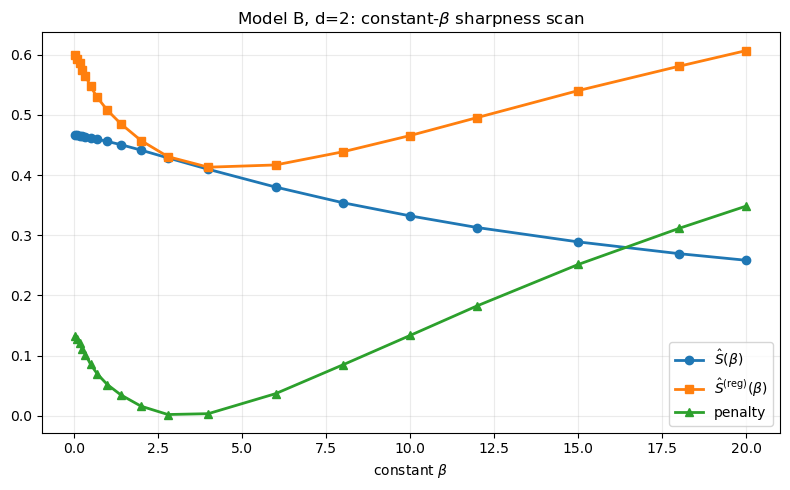

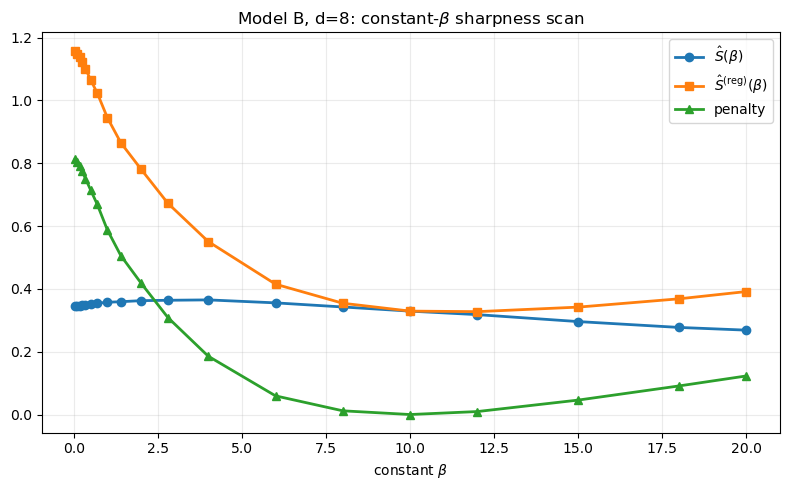

In [18]:
for case_name in [D2_CASE, D8_CASE]:
    sub = const_df[const_df["case_name"] == case_name].sort_values("beta_const")
    d = int(sub["d"].iloc[0])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sub["beta_const"], sub["Shat"], marker="o", linewidth=2, label=r"$\hat S(\beta)$")
    ax.plot(sub["beta_const"], sub["Sreg"], marker="s", linewidth=2, label=r"$\hat S^{(\mathrm{reg})}(\beta)$")
    ax.plot(sub["beta_const"], sub["penalty"], marker="^", linewidth=2, label="penalty")
    ax.set_xlabel(r"constant $\beta$")
    ax.set_title(fr"Model B, d={d}: constant-$\beta$ sharpness scan")
    ax.legend()
    plt.tight_layout()
    savefig_all(fig, f"fig_modelB_const_scan_{case_name}")

## Hierarchical optimization, warm-started from the best constant beta

In [20]:
hier_rows = []
hier_best_records = {}
hier_series = {}

for case_name in [D2_CASE, D8_CASE]:
    print("=" * 80)
    print(f"Hierarchical optimization for {case_name}")

    best_const_row = best_const_df[best_const_df["case_name"] == case_name].iloc[0]
    b_parent = np.array([float(best_const_row["beta_const"])], dtype=float)

    traj_f = []
    level_marks = []
    level_records = {}

    for L in LEVELS:
        if L == 1:
            b_init = b_parent.copy()
        else:
            b_init = prolongate_parent_to_children(b_parent, L)

        start_idx = len(traj_f)
        b_star, f_star = coord_descent_sharpness_reg(case_name, b_init, record=traj_f)
        level_marks.append(start_idx)

        info = evaluate_sharpness(case_name, b_star)
        row = summarize_row(case_name, b_star, info, "hierarchical_sharpness", extra={"L": L, "objective_value": f_star})
        level_records[L] = {
            "betas": np.asarray(b_star, dtype=float).copy(),
            "row": row,
            "info": info,
        }
        hier_rows.append(row)

        print(
            f"[case={case_name}, L={L}] "
            f"Sreg={row['Sreg']:.6f}, Shat={row['Shat']:.6f}, penalty={row['penalty']:.6f}, "
            f"t_star={row['t_star']:.6f}, beta*={np.array2string(np.asarray(b_star), precision=4)}"
        )

        b_parent = np.asarray(b_star, dtype=float).copy()

    hier_best_records[case_name] = level_records
    hier_series[case_name] = {
        "traj_f": np.asarray(traj_f, dtype=float),
        "level_marks": np.asarray(level_marks, dtype=int),
    }

hier_df = pd.DataFrame(hier_rows).sort_values(["case_name", "L"]).reset_index(drop=True)
display(hier_df)
save_table(hier_df, "hierarchical_sharpness_summary_modelB")

Hierarchical optimization for regular_3x3_d2
[case=regular_3x3_d2, L=1] Sreg=0.410851, Shat=0.394624, penalty=0.016227, t_star=0.540283, beta*=[5.]
[case=regular_3x3_d2, L=2] Sreg=0.369709, Shat=0.367875, penalty=0.001834, t_star=0.513543, beta*=[15.   1.5]
[case=regular_3x3_d2, L=4] Sreg=0.354918, Shat=0.351348, penalty=0.003570, t_star=0.518895, beta*=[1.5e+01 2.0e+01 2.0e+00 1.0e-03]
[case=regular_3x3_d2, L=8] Sreg=0.354947, Shat=0.351328, penalty=0.003619, t_star=0.519024, beta*=[1.5e+01 1.5e+01 2.0e+01 2.0e+01 2.0e+00 2.0e+00 1.0e-03 1.0e-03]
Hierarchical optimization for hypercube_random9_d8
[case=hypercube_random9_d8, L=1] Sreg=0.326103, Shat=0.323246, penalty=0.002857, t_star=0.516902, beta*=[11.]
[case=hypercube_random9_d8, L=2] Sreg=0.302124, Shat=0.301109, penalty=0.001015, t_star=0.510077, beta*=[20.  9.]
[case=hypercube_random9_d8, L=4] Sreg=0.302270, Shat=0.301232, penalty=0.001038, t_star=0.510186, beta*=[20. 20.  9.  9.]
[case=hypercube_random9_d8, L=8] Sreg=0.302098, S

,case_name,d,kind,betas,Shat,t_star,penalty,Sreg,L,objective_value
0,hypercube_random9_d8,8,hierarchical_sharpness,[11.],0.323246,0.516902,0.002857,0.326103,1,0.326103
1,hypercube_random9_d8,8,hierarchical_sharpness,"[20., 9.]",0.301109,0.510077,0.001015,0.302124,2,0.302124
2,hypercube_random9_d8,8,hierarchical_sharpness,"[20., 20., 9., 9.]",0.301232,0.510186,0.001038,0.302270,4,0.302270
3,hypercube_random9_d8,8,hierarchical_sharpness,"[20. , 20. , 20. , 20. , 9.5, 9. , 9. , 9. ]",0.300792,0.511431,0.001307,0.302098,8,0.302098
4,regular_3x3_d2,2,hierarchical_sharpness,[5.],0.394624,0.540283,0.016227,0.410851,1,0.410851
5,regular_3x3_d2,2,hierarchical_sharpness,"[15. , 1.5]",0.367875,0.513543,0.001834,0.369709,2,0.369709
6,regular_3x3_d2,2,hierarchical_sharpness,"[1.5e+01, 2.0e+01, 2.0e+00, 1.0e-03]",0.351348,0.518895,0.003570,0.354918,4,0.354918
7,regular_3x3_d2,2,hierarchical_sharpness,"[1.5e+01, 1.5e+01, 2.0e+01, 2.0e+01, 2.0e+00, ...",0.351328,0.519024,0.003619,0.354947,8,0.354947


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelB_sharpness_main/hierarchical_sharpness_summary_modelB.csv


### Best PWC-8 per case

In [22]:
best_pwc8_rows = []
for case_name in [D2_CASE, D8_CASE]:
    best_pwc8_rows.append(hier_best_records[case_name][8]["row"])

best_pwc8_df = pd.DataFrame(best_pwc8_rows).sort_values("case_name").reset_index(drop=True)
display(best_pwc8_df)
save_table(best_pwc8_df, "best_pwc8_per_case_modelB_sharpness")

,case_name,d,kind,betas,Shat,t_star,penalty,Sreg,L,objective_value
0,hypercube_random9_d8,8,hierarchical_sharpness,"[20. , 20. , 20. , 20. , 9.5, 9. , 9. , 9. ]",0.300792,0.511431,0.001307,0.302098,8,0.302098
1,regular_3x3_d2,2,hierarchical_sharpness,"[1.5e+01, 1.5e+01, 2.0e+01, 2.0e+01, 2.0e+00, ...",0.351328,0.519024,0.003619,0.354947,8,0.354947


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelB_sharpness_main/best_pwc8_per_case_modelB_sharpness.csv


### Compare best constant vs best PWC-8

In [23]:
cmp_rows = []
for case_name in [D2_CASE, D8_CASE]:
    const_row = best_const_df[best_const_df["case_name"] == case_name].iloc[0]
    pwc8_row = best_pwc8_df[best_pwc8_df["case_name"] == case_name].iloc[0]
    cmp_rows.append({
        "case_name": case_name,
        "d": int(const_row["d"]),
        "const_beta": float(const_row["beta_const"]),
        "const_Shat": float(const_row["Shat"]),
        "const_t_star": float(const_row["t_star"]),
        "const_penalty": float(const_row["penalty"]),
        "const_Sreg": float(const_row["Sreg"]),
        "pwc8_Shat": float(pwc8_row["Shat"]),
        "pwc8_t_star": float(pwc8_row["t_star"]),
        "pwc8_penalty": float(pwc8_row["penalty"]),
        "pwc8_Sreg": float(pwc8_row["Sreg"]),
        "pwc8_betas": pwc8_row["betas"],
        "improvement_Sreg": float(const_row["Sreg"]) - float(pwc8_row["Sreg"]),
    })

cmp_df = pd.DataFrame(cmp_rows).sort_values("case_name").reset_index(drop=True)
display(cmp_df)
save_table(cmp_df, "best_constant_vs_best_pwc8_modelB_sharpness")

,case_name,d,const_beta,const_Shat,const_t_star,const_penalty,const_Sreg,pwc8_Shat,pwc8_t_star,pwc8_penalty,pwc8_Sreg,pwc8_betas,improvement_Sreg
0,hypercube_random9_d8,8,12.0,0.318100,0.530840,0.009511,0.327611,0.300792,0.511431,0.001307,0.302098,"[20. , 20. , 20. , 20. , 9.5, 9. , 9. , 9. ]",0.025513
1,regular_3x3_d2,2,4.0,0.409708,0.518679,0.003489,0.413197,0.351328,0.519024,0.003619,0.354947,"[1.5e+01, 1.5e+01, 2.0e+01, 2.0e+01, 2.0e+00, ...",0.058250


saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelB_sharpness_main/best_constant_vs_best_pwc8_modelB_sharpness.csv


### Schedule profiles over time

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_schedule_profiles_regular_3x3_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_schedule_profiles_regular_3x3_d2.png
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_schedule_profiles_hypercube_random9_d8.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_schedule_profiles_hypercube_random9_d8.png


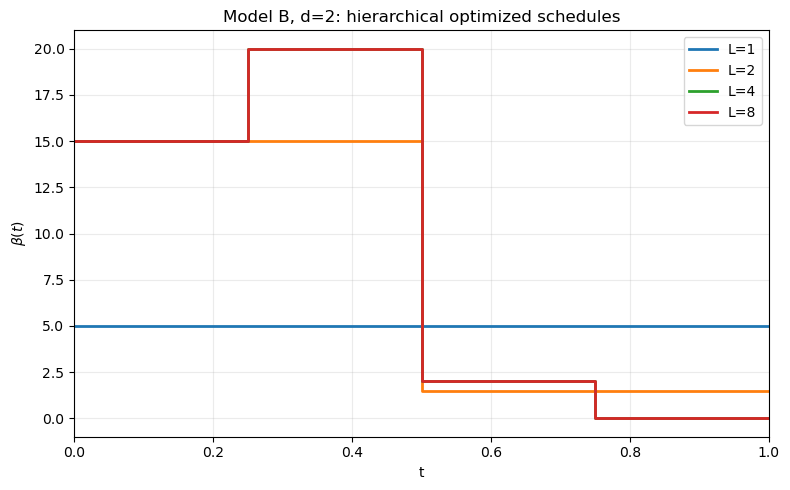

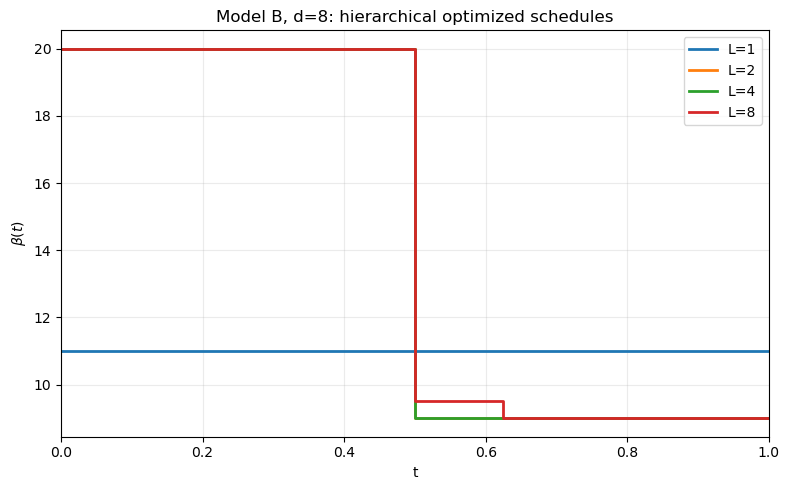

In [24]:
for case_name in [D2_CASE, D8_CASE]:
    d = TARGET_META[case_name]["d"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for L in LEVELS:
        rec = hier_best_records[case_name][L]["betas"]
        x, y = step_plot_from_betas(rec)
        ax.plot(x, y, linewidth=2, label=f"L={L}")
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("t")
    ax.set_ylabel(r"$\beta(t)$")
    ax.set_title(fr"Model B, d={d}: hierarchical optimized schedules")
    ax.legend()
    plt.tight_layout()
    savefig_all(fig, f"fig_modelB_schedule_profiles_{case_name}")

### Best constant vs best PWC-8 Ahat curves

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_best_const_vs_pwc8_Ahat_regular_3x3_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_best_const_vs_pwc8_Ahat_regular_3x3_d2.png
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_best_const_vs_pwc8_Ahat_hypercube_random9_d8.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_best_const_vs_pwc8_Ahat_hypercube_random9_d8.png


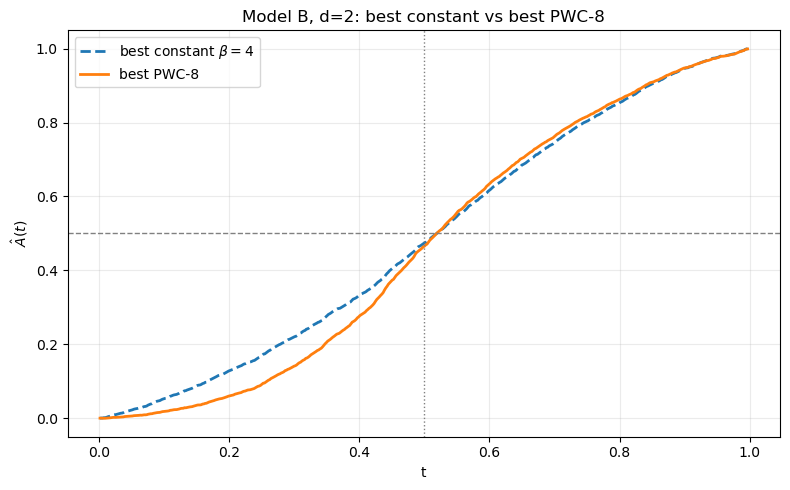

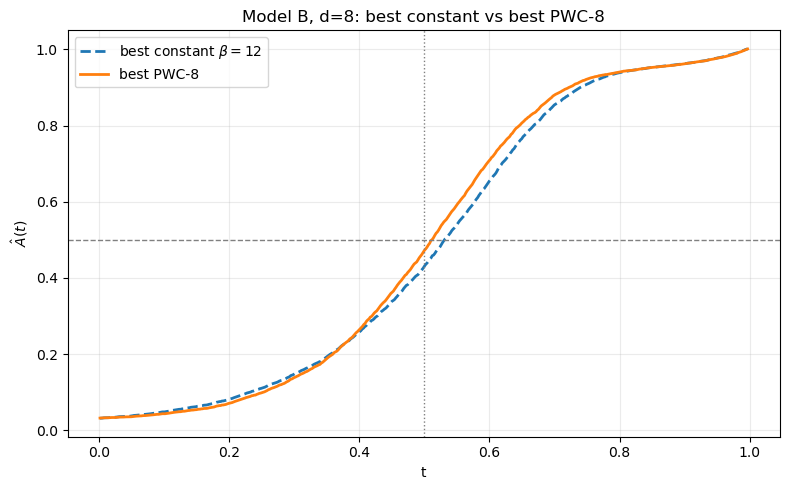

In [25]:
for case_name in [D2_CASE, D8_CASE]:
    d = TARGET_META[case_name]["d"]
    const_row = best_const_df[best_const_df["case_name"] == case_name].iloc[0]
    const_beta = float(const_row["beta_const"])
    const_info = const_infos[(case_name, const_beta)]
    pwc8_info = hier_best_records[case_name][8]["info"]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(const_info["times"], const_info["Ahat"], linewidth=2, linestyle="--", label=fr"best constant $\beta={const_beta:g}$")
    ax.plot(pwc8_info["times"], pwc8_info["Ahat"], linewidth=2, label="best PWC-8")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    ax.axvline(T_TRANS, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("t")
    ax.set_ylabel(r"$\hat A(t)$")
    ax.set_title(fr"Model B, d={d}: best constant vs best PWC-8")
    ax.legend()
    plt.tight_layout()
    savefig_all(fig, f"fig_modelB_best_const_vs_pwc8_Ahat_{case_name}")

### Convergence plots

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_hierarchical_convergence_regular_3x3_d2.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_hierarchical_convergence_regular_3x3_d2.png
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_hierarchical_convergence_hypercube_random9_d8.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_hierarchical_convergence_hypercube_random9_d8.png


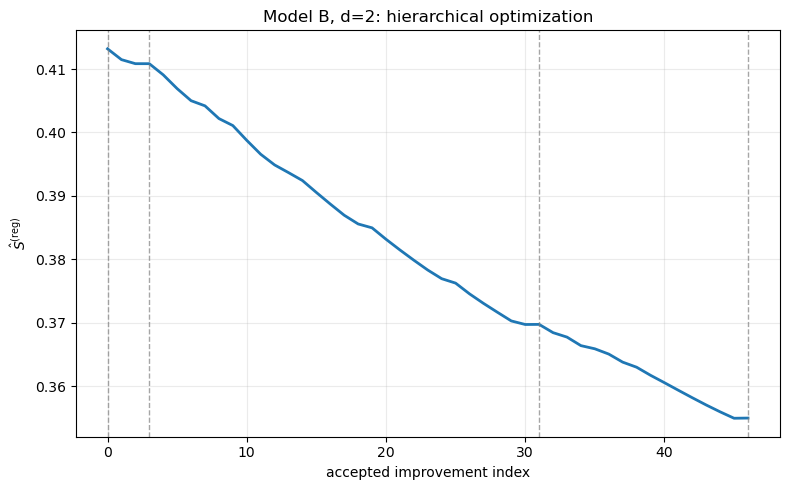

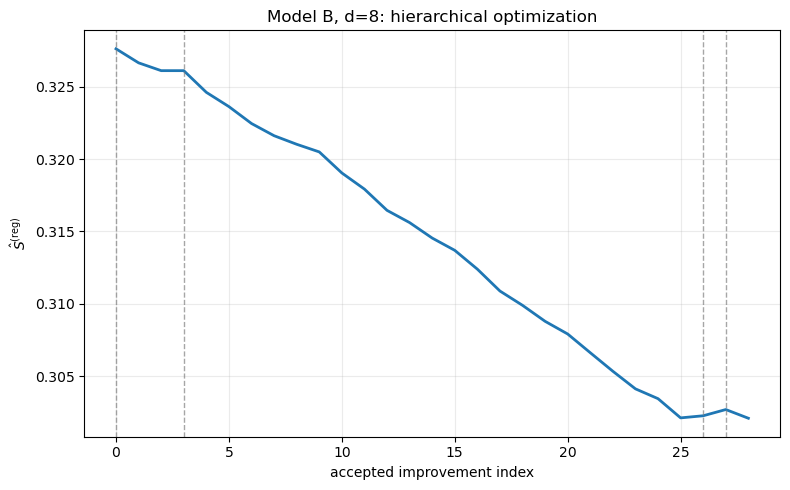

In [26]:
for case_name in [D2_CASE, D8_CASE]:
    d = TARGET_META[case_name]["d"]
    fig, ax = plt.subplots(figsize=(8, 5))
    traj_f = hier_series[case_name]["traj_f"]
    level_marks = hier_series[case_name]["level_marks"]
    ax.plot(np.arange(len(traj_f)), traj_f, linewidth=2)
    for m in level_marks:
        ax.axvline(m, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("accepted improvement index")
    ax.set_ylabel(r"$\hat S^{(\mathrm{reg})}$")
    ax.set_title(fr"Model B, d={d}: hierarchical optimization")
    plt.tight_layout()
    savefig_all(fig, f"fig_modelB_hierarchical_convergence_{case_name}")

## Manifest

In [27]:
manifest = {
    "repo_root": str(ROOT),
    "model": "B",
    "cases": [D2_CASE, D8_CASE],
    "A_grid": A_GRID,
    "sigma": SIGMA,
    "K": K,
    "levels": LEVELS,
    "lam_trans": LAM_TRANS,
    "t_trans": T_TRANS,
    "penalty_type": "two_sided_abs_square",
    "beta_min": BETA_MIN,
    "beta_max": BETA_MAX,
    "d8_random_seed": D8_RANDOM_SEED,
    "beta_sweep_by_case": {k: v for k, v in BETA_SWEEP_BY_CASE.items()},
}
save_json(manifest, "manifest_modelB_sharpness_main")

saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/tables/modelB_sharpness_main/manifest_modelB_sharpness_main.json


Best constant-beta schedule in Model B d=2: [4.]
Best PWC-8 schedule in Model B d=2: [1.5e+01 1.5e+01 2.0e+01 2.0e+01 2.0e+00 2.0e+00 1.0e-03 1.0e-03]
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_d2_two_row_evolution.pdf
saved: /Users/chertkov/Dropbox/Working/NewPID/NewAdaPID-final/figs/modelB_sharpness_main/fig_modelB_d2_two_row_evolution.png


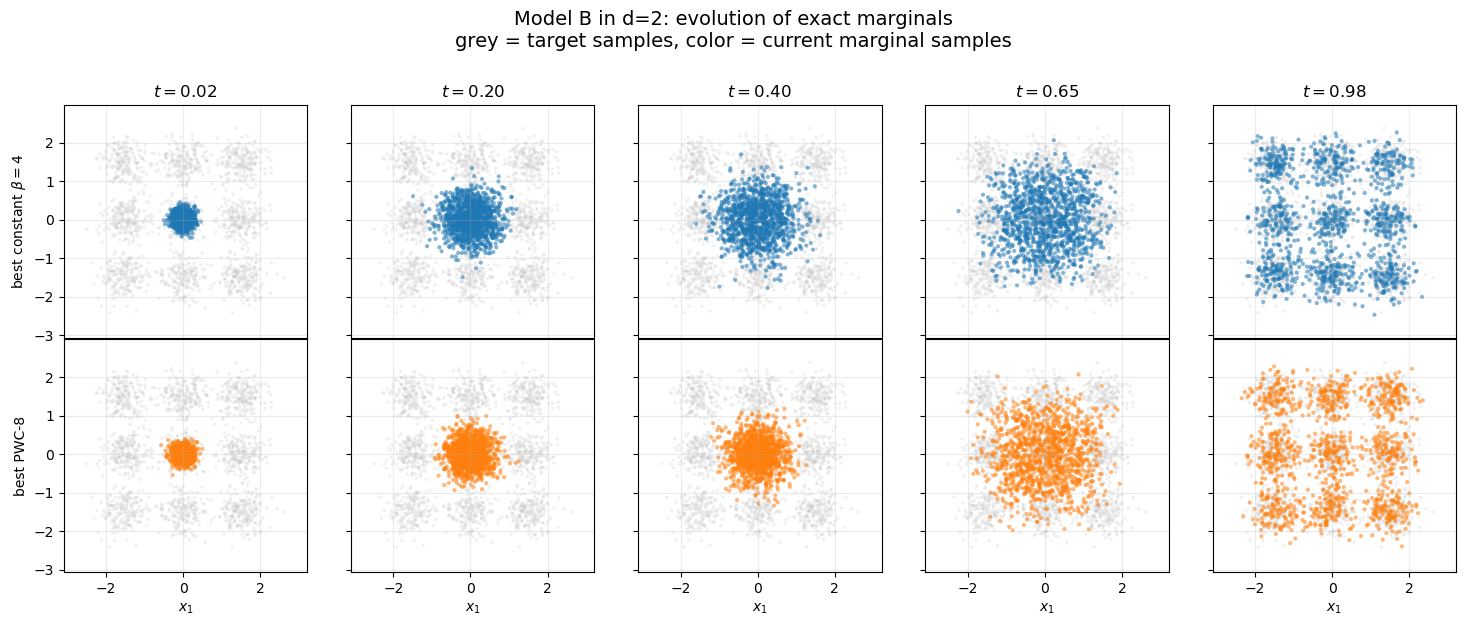

In [29]:
# %% [markdown]
# ### Two-row evolution figure in d=2:
# top = best constant-beta schedule, bottom = best PWC-8 schedule

# %%
from lqgm_pid_ada import exact_marginal_gmm

import numpy as np
import matplotlib.pyplot as plt

# --- configuration ---
CASE_NAME_D2 = D2_CASE
D2_TIMES = [0.02, 0.20, 0.40, 0.65, 0.98]
N_TARGET_SCATTER = 1800
N_CURRENT_SCATTER = 1200
TOP_COLOR = "tab:blue"
BOTTOM_COLOR = "tab:orange"
TARGET_COLOR = "0.75"   # grey
SCATTER_SIZE_TARGET = 6
SCATTER_SIZE_CURRENT = 9
ALPHA_TARGET = 0.22
ALPHA_CURRENT = 0.55

# --- helpers ---
def _extract_gmm_parts(gmm):
    """
    Accept either:
      - dict with keys 'weights','means','covs'
      - object with attributes weights, means, covs
    Return NumPy arrays.
    """
    if isinstance(gmm, dict):
        weights = gmm["weights"]
        means = gmm["means"]
        covs = gmm["covs"]
    else:
        weights = gmm.weights
        means = gmm.means
        covs = gmm.covs

    if hasattr(weights, "detach"):
        weights = weights.detach().cpu().numpy()
    else:
        weights = np.asarray(weights)

    if hasattr(means, "detach"):
        means = means.detach().cpu().numpy()
    else:
        means = np.asarray(means)

    if hasattr(covs, "detach"):
        covs = covs.detach().cpu().numpy()
    else:
        covs = np.asarray(covs)

    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    means = np.asarray(means, dtype=float)
    covs = np.asarray(covs, dtype=float)
    return weights, means, covs


def sample_from_gmm(gmm, n, seed=0):
    """
    Simple NumPy mixture sampler from either the target object or an exact marginal GMM dict.
    """
    rng = np.random.default_rng(seed)
    weights, means, covs = _extract_gmm_parts(gmm)
    K = len(weights)
    d = means.shape[1]

    comps = rng.choice(K, size=n, p=weights)
    out = np.empty((n, d), dtype=float)
    for k in range(K):
        idx = np.where(comps == k)[0]
        if len(idx) == 0:
            continue
        out[idx] = rng.multivariate_normal(mean=means[k], cov=covs[k], size=len(idx))
    return out


def axis_limits_from_samples(*arrays, pad=0.7):
    all_xy = np.vstack(arrays)
    xmin, ymin = all_xy.min(axis=0)
    xmax, ymax = all_xy.max(axis=0)
    return (xmin - pad, xmax + pad), (ymin - pad, ymax + pad)


# --- recover best d=2 schedules from the notebook state ---
d = TARGET_META[CASE_NAME_D2]["d"]
assert d == 2, "This figure cell is intended for the d=2 Model B case."

best_const_row_d2 = best_const_df[best_const_df["case_name"] == CASE_NAME_D2].iloc[0]
best_const_beta_d2 = float(best_const_row_d2["beta_const"])
best_const_schedule_d2 = np.array([best_const_beta_d2], dtype=float)

best_pwc8_schedule_d2 = hier_best_records[CASE_NAME_D2][8]["betas"].copy()

print("Best constant-beta schedule in Model B d=2:", best_const_schedule_d2)
print("Best PWC-8 schedule in Model B d=2:", best_pwc8_schedule_d2)

# --- build target and PIDs using the actual notebook API ---
target_d2 = TARGETS[CASE_NAME_D2]
pid_const_d2 = build_pid(CASE_NAME_D2, best_const_schedule_d2)
pid_pwc8_d2 = build_pid(CASE_NAME_D2, best_pwc8_schedule_d2)

# --- sample target once and reuse in every panel ---
target_samples = sample_from_gmm(target_d2, N_TARGET_SCATTER, seed=2025)

# --- precompute current marginal samples at chosen times ---
const_samples_by_t = {}
pwc_samples_by_t = {}

for j, t in enumerate(D2_TIMES):
    gm_const = exact_marginal_gmm(pid_const_d2, float(t))
    gm_pwc = exact_marginal_gmm(pid_pwc8_d2, float(t))

    const_samples_by_t[t] = sample_from_gmm(gm_const, N_CURRENT_SCATTER, seed=3100 + j)
    pwc_samples_by_t[t] = sample_from_gmm(gm_pwc, N_CURRENT_SCATTER, seed=4100 + j)

# --- choose common axis limits across all panels ---
all_current = [const_samples_by_t[t] for t in D2_TIMES] + [pwc_samples_by_t[t] for t in D2_TIMES]
xlim, ylim = axis_limits_from_samples(target_samples, *all_current, pad=0.6)

# --- make figure ---
fig, axes = plt.subplots(
    2, len(D2_TIMES),
    figsize=(3.0 * len(D2_TIMES), 6.0),
    sharex=True, sharey=True
)

row_titles = [
    rf"best constant $\beta={best_const_beta_d2:g}$",
    r"best PWC-8"
]

for col, t in enumerate(D2_TIMES):
    # top row: best constant-beta
    ax = axes[0, col]
    ax.scatter(
        target_samples[:, 0], target_samples[:, 1],
        s=SCATTER_SIZE_TARGET, c=TARGET_COLOR, alpha=ALPHA_TARGET, edgecolors="none"
    )
    xs = const_samples_by_t[t]
    ax.scatter(
        xs[:, 0], xs[:, 1],
        s=SCATTER_SIZE_CURRENT, c=TOP_COLOR, alpha=ALPHA_CURRENT, edgecolors="none"
    )
    ax.set_title(rf"$t={t:.2f}$")
    if col == 0:
        ax.set_ylabel(row_titles[0])

    # bottom row: best PWC-8
    ax = axes[1, col]
    ax.scatter(
        target_samples[:, 0], target_samples[:, 1],
        s=SCATTER_SIZE_TARGET, c=TARGET_COLOR, alpha=ALPHA_TARGET, edgecolors="none"
    )
    xs = pwc_samples_by_t[t]
    ax.scatter(
        xs[:, 0], xs[:, 1],
        s=SCATTER_SIZE_CURRENT, c=BOTTOM_COLOR, alpha=ALPHA_CURRENT, edgecolors="none"
    )
    if col == 0:
        ax.set_ylabel(row_titles[1])
    ax.set_xlabel(r"$x_1$")

for ax in axes.ravel():
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle(
    "Model B in d=2: evolution of exact marginals\n"
    "grey = target samples, color = current marginal samples",
    y=1.02,
    fontsize=14
)
plt.tight_layout()

savefig_all(fig, "fig_modelB_d2_two_row_evolution")
plt.show()